In [1]:
import json

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

In [2]:
sim = "m12b"
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"
# fire_dir = sim_dir + sim + "/" + sim + "_res7100"
snap = 600

pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_nbody = agama.Potential(pot_file)
af = agama.ActionFinder(pot_nbody, interp=False)

In [3]:
lz_scale = 10**-3
et_scale = 10**-5

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

lz_grid = np.linspace(-10, 10, 500)
et_grid = np.linspace(-4, 0, 500)
XX, YY = np.meshgrid(lz_grid, et_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

# grid cell area (for proper normalization)
dz = (lz_grid[1] - lz_grid[0]) * (et_grid[1] - et_grid[0])

Zis_list = []
Zid_list = []

Zes_list = []
Zed_list = []

for it_id in ghost_data.keys():
    print(it_id)

    src_dat = ghost_data[it_id]["source"]

    situ_msk = src_dat["grpid"][()] == 0
    smsk = src_dat["s_flag"][()].astype(bool)

    pxyz = src_dat["pxyz_snap600"]
    vxyz = src_dat["vxyz_snap600"]

    pxyz = np.array(pxyz)
    vxyz = np.array(vxyz)

    posvel = np.column_stack((pxyz, vxyz))

    ek = 0.5 * np.sum(vxyz**2, axis=1)
    ep = pot_nbody.potential(pxyz)
    et = ek + ep

    ioms = af(posvel)
    lz = ioms[:, 2]

    # remove invalid values
    valid = np.isfinite(lz) & np.isfinite(et)
    lz = lz[valid]
    et = et[valid]
    smsk = smsk[valid]
    situ_msk = situ_msk[valid]

    # masks
    mask_is = situ_msk & smsk
    mask_id = situ_msk & (~smsk)

    mask_es = ~situ_msk & smsk
    mask_ed = ~situ_msk & (~smsk)

    # scaled values
    lz_is = lz[mask_is] * lz_scale
    et_is = et[mask_is] * et_scale

    lz_id = lz[mask_id] * lz_scale
    et_id = et[mask_id] * et_scale

    lz_es = lz[mask_es] * lz_scale
    et_es = et[mask_es] * et_scale

    lz_ed = lz[mask_ed] * lz_scale
    et_ed = et[mask_ed] * et_scale

    if len(lz_is) > 5:
        kdeis = gaussian_kde(np.vstack([lz_is, et_is]))
        Zis = kdeis(grid_positions).reshape(XX.shape)

        # normalize → equal weight per iteration
        Zis /= Zis.sum() * dz

        Zis_list.append(Zis)

    if len(lz_id) > 5:
        kdeid = gaussian_kde(np.vstack([lz_id, et_id]))
        Zid = kdeid(grid_positions).reshape(XX.shape)

        Zid /= Zid.sum() * dz

        Zid_list.append(Zid)

    if len(lz_es) > 5:
        kdees = gaussian_kde(np.vstack([lz_es, et_es]))
        Zes = kdees(grid_positions).reshape(XX.shape)

        # normalize → equal weight per iteration
        Zes /= Zes.sum() * dz

        Zes_list.append(Zes)

    if len(lz_ed) > 5:
        kdeed = gaussian_kde(np.vstack([lz_ed, et_ed]))
        Zed = kdeed(grid_positions).reshape(XX.shape)

        Zed /= Zed.sum() * dz

        Zed_list.append(Zed)

it000
it001


KeyboardInterrupt: 

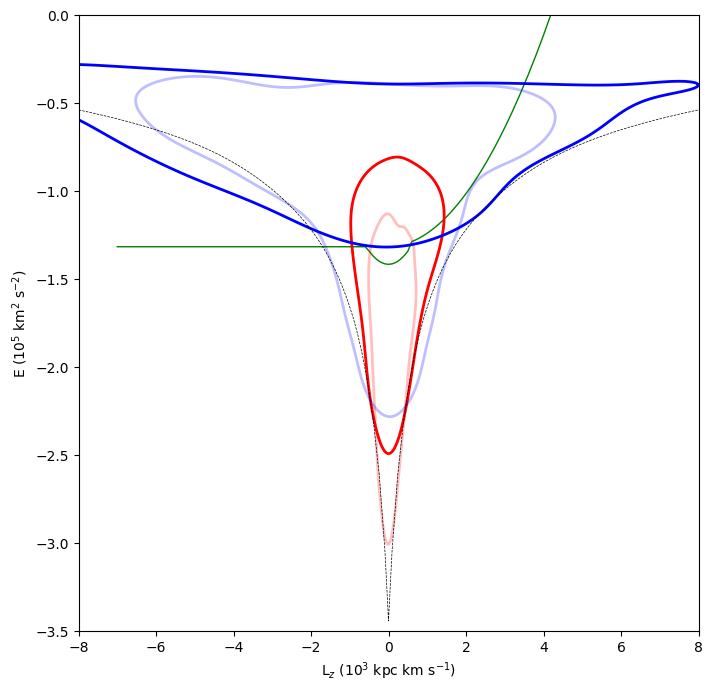

In [ ]:
# # cont_levels = [0.2, 0.5, 0.8]
# cont_levels = [0.75]

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

# # if in_msk:
# #     col = "r"
# # else:
# #     col = "b"

# for cont_level in cont_levels:
#     if len(Zis_list) > 0:
#         Zis_avg = np.mean(Zis_list, axis=0)
#         # Z0_avg[XX <= 4] = 0
#         Zisf = Zis_avg.ravel()
#         idx = np.argsort(Zisf)[::-1]
#         Ziss = Zisf[idx]
#         Zis_cdf = np.cumsum(Ziss)
#         Zis_cdf /= Zis_cdf[-1]
#         level = Ziss[np.searchsorted(Zis_cdf, cont_level)]
#         ax.contour(XX, YY, Zis_avg, levels=[level], colors="r", linewidths=2)

#     if len(Zid_list) > 0:
#         Zid_avg = np.mean(Zid_list, axis=0)
#         # Z1_avg[XX <= 4] = 0
#         Zidf = Zid_avg.ravel()
#         idx = np.argsort(Zidf)[::-1]
#         Zids = Zidf[idx]
#         Zid_cdf = np.cumsum(Zids)
#         Zid_cdf /= Zid_cdf[-1]
#         level = Zids[np.searchsorted(Zid_cdf, cont_level)]
#         ax.contour(XX, YY, Zid_avg, levels=[level], colors="r", linewidths=2, alpha=0.25)

#     if len(Zes_list) > 0:
#         Zes_avg = np.mean(Zes_list, axis=0)
#         # Z0_avg[XX <= 4] = 0
#         Zesf = Zes_avg.ravel()
#         idx = np.argsort(Zesf)[::-1]
#         Zess = Zesf[idx]
#         Zes_cdf = np.cumsum(Zess)
#         Zes_cdf /= Zes_cdf[-1]
#         level = Zess[np.searchsorted(Zes_cdf, cont_level)]
#         ax.contour(XX, YY, Zes_avg, levels=[level], colors="b", linewidths=2)

#     if len(Zed_list) > 0:
#         Zed_avg = np.mean(Zed_list, axis=0)
#         # Z1_avg[XX <= 4] = 0
#         Zedf = Zed_avg.ravel()
#         idx = np.argsort(Zedf)[::-1]
#         Zeds = Zedf[idx]
#         Zed_cdf = np.cumsum(Zeds)
#         Zed_cdf /= Zed_cdf[-1]
#         level = Zeds[np.searchsorted(Zed_cdf, cont_level)]
#         ax.contour(XX, YY, Zed_avg, levels=[level], colors="b", linewidths=2, alpha=0.25)

# r_c = np.arange(-100, 100, 0.5)
# xyz_c = np.column_stack((r_c, r_c * 0, r_c * 0))
# vel_rot = np.sqrt(-r_c * pot_nbody.force(xyz_c)[:, 0])
# vxyz_c = np.column_stack((vel_rot * 0, vel_rot, vel_rot * 0))
# posvel_c = np.concatenate((xyz_c, vxyz_c), axis=1)
# ioms_c = af(posvel_c)
# jphi_c = ioms_c[:, 2]
# lz_c = jphi_c
# ep_c = pot_nbody.potential(xyz_c)
# ek_c = 0.5 * np.sum(np.array(vxyz_c) ** 2, axis=1)
# et_c = ek_c + ep_c

# # lz_norm = lz / np.array(lz_c)
# # et_norm = et / np.abs(E_0)

# # plt.scatter(lz[~smsk] * lz_scale, et[~smsk] * et_scale, c="grey", s=5)
# # plt.scatter(lz[smsk] * lz_scale, et[smsk] * et_scale, c="r")

# plt.plot(lz_c * lz_scale, et_c * et_scale, c="k", ls="--", lw=0.5)

# plt.xlim(-8, 8)
# plt.ylim(-3.5, 0)

# plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
# plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")

# # Boundary
# lz_boundary = np.arange(-7, 7, 0.1)
# et_boundary = []
# for lz_b in lz_boundary:
#     if lz_b < -0.58:
#         et_boundary.append(-1.316)
#     elif lz_b < 0.58:
#         et_boundary.append(-1.416 + 0.3 * lz_b**2)
#     else:
#         et_boundary.append(-1.314 + 0.075 * lz_b**2)
# et_boundary = np.array(et_boundary)

# plt.plot(lz_boundary, et_boundary, c="green", lw=1, zorder=0)

# # plt.xlim(-1.75, 1.75)
# # plt.ylim(-2.4, -0.6)

(-3.5, 0.0)

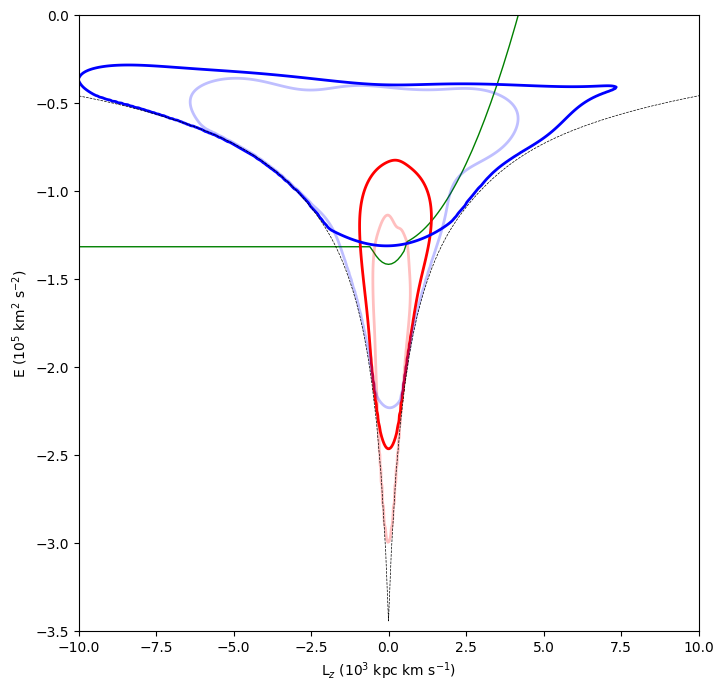

In [ ]:
r_c = np.arange(-100, 100, 0.5)
xyz_c = np.column_stack((r_c, r_c * 0, r_c * 0))
vel_rot = np.sqrt(-r_c * pot_nbody.force(xyz_c)[:, 0])
vxyz_c = np.column_stack((vel_rot * 0, vel_rot, vel_rot * 0))
posvel_c = np.concatenate((xyz_c, vxyz_c), axis=1)
ioms_c = af(posvel_c)
jphi_c = ioms_c[:, 2]
lz_c = jphi_c
ep_c = pot_nbody.potential(xyz_c)
ek_c = 0.5 * np.sum(np.array(vxyz_c) ** 2, axis=1)
et_c = ek_c + ep_c

# cont_levels = [0.2, 0.5, 0.8]
cont_levels = [0.75]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

emin_interp = interp1d(lz_c * lz_scale, et_c * et_scale, bounds_error=False, fill_value=np.nan)

E_min_grid = emin_interp(XX)


def apply_barrier(Z, YY, E_min_grid):
    Z_mod = Z.copy()
    d = YY - E_min_grid

    penalty = np.zeros_like(Z)

    penalty[d < 0] = np.exp(-(-d[d < 0] * 5))
    penalty[YY > 0] = np.exp(-(YY[YY > 0] * 5))

    return Z_mod * (1 - penalty)


def get_level(Z, cont_level):
    Zf = Z.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    return Zs[np.searchsorted(cdf, cont_level)]


for cont_level in cont_levels:
    if len(Zis_list) > 0:
        Z = np.mean(Zis_list, axis=0)
        Zp = gaussian_filter(apply_barrier(Z, YY, E_min_grid), sigma=1.0)
        level = get_level(Zp, cont_level)
        ax.contour(XX, YY, Zp, levels=[level], colors="r", linewidths=2)

    if len(Zid_list) > 0:
        Z = np.mean(Zid_list, axis=0)
        Zp = gaussian_filter(apply_barrier(Z, YY, E_min_grid), sigma=1.0)
        level = get_level(Zp, cont_level)
        ax.contour(XX, YY, Zp, levels=[level], colors="r", linewidths=2, alpha=0.25)

    if len(Zes_list) > 0:
        Z = np.mean(Zes_list, axis=0)
        Zp = gaussian_filter(apply_barrier(Z, YY, E_min_grid), sigma=1.0)
        level = get_level(Zp, cont_level)
        ax.contour(XX, YY, Zp, levels=[level], colors="b", linewidths=2)

    if len(Zed_list) > 0:
        Z = np.mean(Zed_list, axis=0)
        Zp = gaussian_filter(apply_barrier(Z, YY, E_min_grid), sigma=1.0)
        level = get_level(Zp, cont_level)
        ax.contour(XX, YY, Zp, levels=[level], colors="b", linewidths=2, alpha=0.25)

plt.plot(lz_c * lz_scale, et_c * et_scale, c="k", ls="--", lw=0.5)

plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")

# Boundary
lz_boundary = np.arange(-10, 10, 0.1)
et_boundary = []
for lz_b in lz_boundary:
    if lz_b < -0.58:
        et_boundary.append(-1.316)
    elif lz_b < 0.58:
        et_boundary.append(-1.416 + 0.3 * lz_b**2)
    else:
        et_boundary.append(-1.314 + 0.075 * lz_b**2)
et_boundary = np.array(et_boundary)

plt.plot(lz_boundary, et_boundary, c="green", lw=1, zorder=0)

plt.xlim(-10, 10)
plt.ylim(-3.5, 0)
